# Projeto M1 – Operações Pontuais e Filtragem Espacial

## Fluxo do Processamento

1. Seleção das imagens: escolher três radiografias de uma mesma região anatômica do conjunto
MURA e justificar a seleção.
2. Caracterização inicial: apresentar as imagens originais e identificar seus principais problemas
de qualidade.
3. Inserção de ruído: adicionar ruído controlado às imagens e registrar os parâmetros utilizados.
4. Operação pontual: aplicar uma técnica de transformação de intensidade escolhida pelo grupo.
5. Suavização: reduzir o ruído utilizando uma técnica de filtragem espacial.
6. Aguçamento: realçar detalhes ou estruturas utilizando uma técnica espacial adequada.
7. Segunda configuração: modificar uma técnica, parâmetro ou ordem do pipeline e repetir o
processamento.
8. Análise por métricas: selecionar duas métricas dentre as apresentadas em aula e utilizá-las
para comparar as imagens original, degradada e processadas. A escolha das métricas deverá
ser justificada.
9. Discussão: identificar qual configuração apresentou o melhor resultado para cada imagem e
discutir situações em que uma técnica apresentou comportamento inadequado

### Importações gerais

In [261]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, metrics
from google.colab.patches import cv2_imshow

### Inserção de ruído

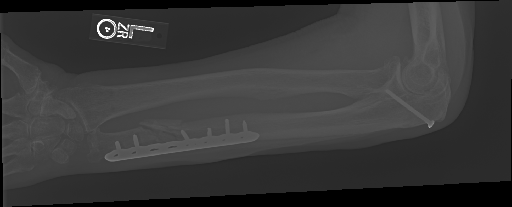

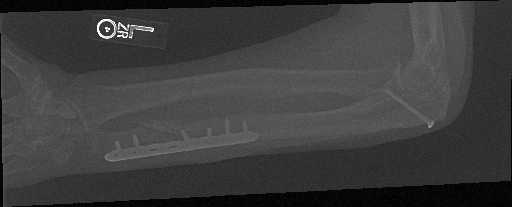

In [262]:
img = cv2.imread('image1.png',0)

noise = np.zeros(img.shape, np.uint8)
cv2.randu(noise, 0, 12) # 0 até 25 deixa a imagem somente mais clara quando adiciona
noisy_img = cv2.add(img, noise)

# noise = np.random.randint(-12, 12, img.shape).astype(np.int16) # valores aleatórios de -12 até 12
# noisy_img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8) # mantém valores dentro de 0 e 255

cv2_imshow(img)
cv2_imshow(noisy_img)

img = noisy_img

### Operação pontual: transformação de intensidade

Equalização de histograma

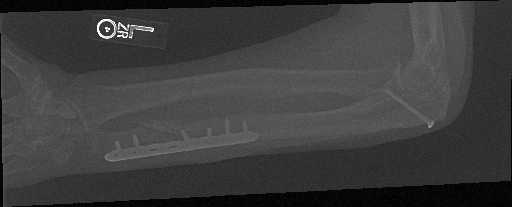

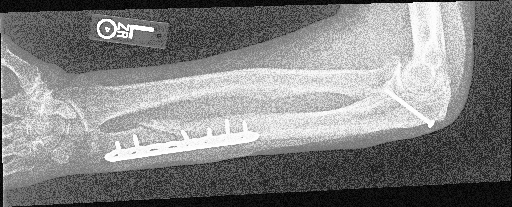

In [263]:
def histogramaNormalizado(im):
  histogram = np.zeros(256)

  for i in range(im.shape[0]):
    for j in range(im.shape[1]):
      histogram[im[i, j]] += 1

  return histogram/(im.shape[0]*im.shape[1])

def histogramaAcumulado(histogram):
  acumulados = np.zeros(256)
  soma = 0

  for k in range(256):
    soma += histogram[k]
    acumulados[k] = soma

  return acumulados

def histEqualization(im):
  img = im.copy()

  # histograma

  histogram = histogramaNormalizado(img)

  # histograma equalizado e imagem resultante

  sum = 0

  acumulados = histogramaAcumulado(histogram)

  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      img[i,j] = round(acumulados[img[i,j]]*255)

  return img

img_equalizada = histEqualization(img)

cv2_imshow(img)
cv2_imshow(img_equalizada)

img = img_equalizada

###Suavização (Filtro de Média)

Função de filtro de média e função assitente de padding por replicação.

In [264]:
def padding_replicacaoBW(imagem, k):
    """
    imagem deve ser BW
    Adiciona padding por replicação nas bordas da imagem.
    O tamanho do padding é definido por:
        r = (k - 1) / 2
    """
    altura, largura = imagem.shape
    r = k // 2

    # Cria uma nova imagem com espaço para o padding
    imagem_padding = np.zeros(
        (altura + 2 * r, largura + 2 * r),
        dtype=imagem.dtype
    )

    # o imagem original fica no centro
    for i in range(altura):
        for j in range(largura):
            imagem_padding[i + r, j + r] = imagem[i, j]


    for j in range(largura):
        for p in range(r): # Linha superior
            imagem_padding[p, j + r] = imagem[0, j]
        for p in range(r): # Linha inferior
            imagem_padding[altura + r + p, j + r] = imagem[altura - 1, j]

    for i in range(altura + 2 * r):
        for p in range(r): # Coluna esquerda
            imagem_padding[i, p] = imagem_padding[i, r]
        for p in range(r): # Coluna direita
            imagem_padding[i, largura + r + p] = imagem_padding[i, largura + r - 1]

    return imagem_padding


def filtro_mediaBW(imagem, k):
    """Aplica um filtro de média(box blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1."""
    altura, largura = imagem.shape
    imagem_padding = padding_replicacaoBW(imagem, k)

    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for i in range(altura):
        for j in range(largura):
            soma = 0.0

            # Percorre a máscara k x k
            for u in range(k):
                for v in range(k):
                    soma += float(imagem_padding[i + u, j + v])

            # Média dos k^2 pixels
            imagem_filtrada[i, j] = soma / (k * k)

    return imagem_filtrada

def filtro_media_otimizadoBW(imagem, k):
    """
    Aplica um filtro de média(box blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1.
    """
    altura, largura = imagem.shape
    r = k // 2
    imagem_padding = padding_replicacaoBW(imagem, k)
    altura_pad, largura_pad = imagem_padding.shape

    # Para cada linha do padding, calculamos a soma de cada janela horizontal de tamanho k.
    soma_horizontal = np.zeros((altura_pad, largura), dtype=float)

    for i in range(altura_pad):
        soma = 0.0

        for v in range(k):
            soma += float(imagem_padding[i, v])

        soma_horizontal[i, 0] = soma

        for j in range(1, largura):
            pixel_sai = float(imagem_padding[i, j - 1])
            pixel_entra = float(imagem_padding[i, j + k - 1])

            soma = soma - pixel_sai + pixel_entra
            soma_horizontal[i, j] = soma


    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for j in range(largura):
        # Primeira janela vertical
        soma = 0.0

        for u in range(k):
            soma += soma_horizontal[u, j]

        imagem_filtrada[0, j] = soma / (k * k)

        # Deslocamento vertical
        for i in range(1, altura):

            soma = (
                soma
                - soma_horizontal[i - 1, j]
                + soma_horizontal[i + k - 1, j]
            )

            imagem_filtrada[i, j] = soma / (k * k)

    return imagem_filtrada

Função de filtro de mediana e funções assitentes:

In [265]:
def atualizar_lista(tons, quantidades, valor, delta):
    posicao = 0
    while posicao < len(tons) and tons[posicao] < valor:
        posicao += 1

    # O valor já existe
    if posicao < len(tons) and tons[posicao] == valor:
        quantidades[posicao] += delta
        # Se a quantidade chegou a zero, remove o tom das duas listas
        if quantidades[posicao] == 0:
            tons.pop(posicao)
            quantidades.pop(posicao)

    # O valor ainda não existe
    else:
        tons.insert(posicao, valor)
        quantidades.insert(posicao, delta)


def encontrar_mediana_lista(tons, quantidades, quantidade_total):
    """
    Encontra a mediana usando os tons ordenados e suas respectivas quantidades.
    """
    posicao_mediana = quantidade_total // 2
    acumulado = 0

    for i in range(len(tons)):
        acumulado += quantidades[i]
        if acumulado > posicao_mediana:
            return tons[i]

def filtro_mediana_otimizadoBW(imagem, k):
    """
    Aplica um filtro de mediana(median blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1.
    """
    altura, largura = imagem.shape
    imagem_padding = padding_replicacaoBW(imagem, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float )

    for i in range(altura):
        tons = [] # Lista ordenada dos tons presentes
        quantidades = []

        for u in range(k):
            for v in range(k):
                valor = int(imagem_padding[i + u, v])
                atualizar_lista(tons, quantidades, valor, +1)

        imagem_filtrada[i, 0] = encontrar_mediana_lista(tons, quantidades, k * k)

        for j in range(1, largura):
            coluna_sai = j - 1
            for u in range(k):
                valor = int(imagem_padding[i + u, coluna_sai])
                atualizar_lista(tons, quantidades, valor, -1)


            coluna_entra = j + k - 1
            for u in range(k):
                valor = int(imagem_padding[i + u, coluna_entra])
                atualizar_lista(tons, quantidades, valor, +1)

            # Calcula a nova mediana
            imagem_filtrada[i, j] = encontrar_mediana_lista(tons, quantidades, k * k)

    return imagem_filtrada

Filtro Gaussiano e assistente:

In [266]:
def kernel_gaussiano_1D(k, sigma):
    """
    Gera um kernel Gaussiano 1D de tamanho k.
    k deve ser ímpar e > 1.
    sigma controla a intensidade da suavização.
    """
    if k <= 1 or k % 2 == 0:
        raise ValueError("k deve ser um número ímpar e maior que 1.")

    if sigma <= 0:
        raise ValueError("sigma deve ser maior que 0.")

    r = k // 2
    kernel = np.zeros(k, dtype=float)

    for i in range(k):
        x = i - r
        kernel[i] = np.exp(-(x ** 2) / (2 * sigma ** 2))

    # Normalização: a soma dos pesos deve ser 1
    kernel /= kernel.sum()
    return kernel

def filtro_gaussianoBW(imagem, k, sigma):
    """
    Aplica um filtro Gaussiano separável em uma imagem BW.
    k, tamanho do kernel (ímpar e > 1)
    sigma, desvio padrão da distribuição Gaussiana

    O padding é feito por replicação.
    """

    altura, largura = imagem.shape
    r = k // 2
    kernel = kernel_gaussiano_1D(k, sigma)
    imagem_padding = padding_replicacaoBW(imagem, k)
    altura_pad, largura_pad = imagem_padding.shape

    imagem_horizontal = np.zeros((altura, largura), dtype=float)

    for i in range(altura):
        for j in range(largura):
            soma = 0.0
            for v in range(k):
                soma += (float(imagem_padding[i + r, j + v]) * kernel[v])
            imagem_horizontal[i, j] = soma

    # Fazemos padding novamente na imagem intermediária
    imagem_horizontal_padding = padding_replicacaoBW(imagem_horizontal, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for j in range(largura):
        for i in range(altura):
            soma = 0.0
            for u in range(k):
                soma += (float(imagem_horizontal_padding[i + u, j + r]) * kernel[u])
            imagem_filtrada[i, j] = soma
    return imagem_filtrada

Filtro Bilateral:

In [267]:
def filtro_bilateralBW(imagem, k, sigma_espacial, sigma_intensidade):
    """
    Aplica um filtro bilateral em uma imagem BW.
    k , tamanho da janela, ímpar e > 1
    sigma_espacial, controla a influência da distância espacial(usar valores baseado no tamanho do kernel(k//2 como valor máximo efetivo))
    sigma_intensidade, controla a influência da diferença de intensidade
    (usar valores baseados na variação do ruído(-12 <-> 12) que estamos introduzindo para teste com variação de 1 até 25),
    O padding é feito por replicação.
    """
    if k <= 1 or k % 2 == 0:
        raise ValueError("k deve ser ímpar e maior que 1.")

    if sigma_espacial <= 0:
        raise ValueError("sigma_espacial deve ser maior que 0.")

    if sigma_intensidade <= 0:
        raise ValueError("sigma_intensidade deve ser maior que 0.")

    altura, largura = imagem.shape
    r = k // 2
    imagem_padding = padding_replicacaoBW(imagem, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    pesos_espaciais = np.zeros((k, k), dtype=float)
    for u in range(k):
        for v in range(k):
            dy = u - r
            dx = v - r
            distancia_quadrada = (dx ** 2 + dy ** 2)
            pesos_espaciais[u, v] = np.exp(-distancia_quadrada / (2 * sigma_espacial ** 2))

    pesos_intensidade = np.zeros(256, dtype=float)
    for d in range(256):
        pesos_intensidade[d] = np.exp(-(d ** 2) /(2 * sigma_intensidade ** 2))

    for i in range(altura):
        for j in range(largura):
            pixel_central = int(imagem_padding[i + r, j + r])
            soma_ponderada = 0.0
            soma_pesos = 0.0

            for u in range(k):
                for v in range(k):
                    pixel_vizinho = int(imagem_padding[i + u, j + v])
                    diferenca = abs(pixel_vizinho - pixel_central)
                    peso_espacial = pesos_espaciais[u, v]
                    peso_intensidade = pesos_intensidade[diferenca]
                    peso = (peso_espacial *peso_intensidade)
                    soma_ponderada += (pixel_vizinho * peso)
                    soma_pesos += peso

            imagem_filtrada[i, j] = (
                soma_ponderada / soma_pesos
            )

    return imagem_filtrada

Testes de funções de suavização: Box blur, Median blur, Gaussian blur e Bilateral blur.

Valores com tamanho kernel acima de 5/7 com Box blur acabam destruindo muito os detalhes da imagem.
Considerar passar Box blur várias vezes com kernel pequeno(3) para pequenos ajustes de suavização.

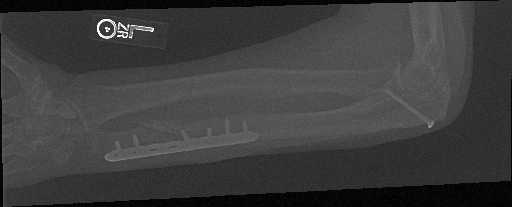

In [268]:
img_suavizada = filtro_media_otimizadoBW(img_equalizada, 5)

cv2_imshow(noisy_img)
# cv2_imshow(img_equalizada)
# cv2_imshow(img_suavizada)

# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 3))
# cv2_imshow(filtro_media_otimizadoBW(filtro_media_otimizadoBW(noisy_img, 3),3))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 5))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 7))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 9))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 11))

# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 3))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 5))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 7))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 9))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 11))
# cv2_imshow(filtro_media_otimizadoBW(filtro_mediana_otimizadoBW(noisy_img, 3),3))

# cv2_imshow(filtro_gaussianoBW(noisy_img, 3, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 3, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, 2))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, 2))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 9, 1))

# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 25))
# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 40))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 25))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 40))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 1, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 2, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 3, 12))

### Testes de Métricas de qualidade
escolher 2 dentre MSE, RMSE, PSNR, SSIM e GMSD, para utilizarmos.

MSE:
utilizada para identificar
distorções espaciais (estruturas - simetria) da
imagem após processamento
– Quanto mais próximo do zero, mais iguais as imagens são

RMSE:
Erro padronizado, mais utilizado que MSE. maior é pior.

PSNR:
É a razão entre a potência máxima de um sinal e a potência máxima do sinal do ruído:
– Medido em dB
– Quanto maior melhor (considerável bom >= 20 dB)
• Boa para avaliar filtros de suavização

SSIM:
métrica baseada em recurso do Sistema Visual Humano (HVS) – Hue, Saturation or Intensity Value.
– O SSIM mede a semelhança entre duas imagens, sendo
uma melhoria em relação a métodos como MSE e PSNR
• Basicamente, calcula a degradação da imagem
para algum processo.
– Vai de -1 a 1, sendo 1 para imagens idênticas

GMSD:
assim como SSIM, é uma métrica para o HSV
• Avalia a distorção causada pelo processamento
entre a imagem de referência e a imagem processada
– Quanto menor o valor melhor a resultado


In [269]:
pip install sporco

In [270]:
import sporco.metric as sm

mse_val = metrics.mean_squared_error(img, noisy_img)

rmse_val = np.sqrt(mse_val)

psnr_val = metrics.peak_signal_noise_ratio(img, noisy_img, data_range=255)

ssim_val = metrics.structural_similarity(img, noisy_img, data_range=255, multichannel=True)

gmsd_val = sm.gmsd(img, noisy_img)

print("MSE(↓): ", mse_val)
print("RMSE(↓): ", rmse_val)
print("PSNR(>=20, bom): ", psnr_val)
print("SSIM(-1<->1): ", ssim_val)
print("GMSD(↓): ", gmsd_val)

MSE(↓):  7425.528400513285
RMSE(↓):  86.17150573428135
PSNR(>=20, bom):  9.42352997388827
SSIM(-1<->1):  0.37608393452030764
GMSD(↓):  0.18427670577739091


Testes de Blurs com métricas

Comparações de Blurs com métricas:
|index|Filtro|k|Repeticoes|RMSE\(↓\)|PSNR\(&gt;=20, bom\)|SSIM\(-1&lt;-&gt;1\)|GMSD\(↓\)|
|---|---|---|---|---|---|---|---|
|0|Box|3|1|6\.120873741575296|32\.39453518518017|0\.8781946974782923|0\.04869728874404877|
|1|Box|3|2|6\.5064358594853395|31\.86394055140702|0\.9031312731313417|0\.06159195094682644|
|2|Box|3|3|7\.124814089685239|31\.07533287612697|0\.9025548908384315|0\.07286044958680761|
|3|Box|5|1|7\.73185447816354|30\.365130177817047|0\.8910843741823492|0\.08324118763460246|
|4|Box|5|2|8\.125284858486248|29\.934031697999075|0\.8897845588831935|0\.09971812970505574|
|5|Box|7|1|8\.666104429093316|29\.37432524657047|0\.8761357264919033|0\.11096916792018292|
|6|Box|7|2|9\.07549413149557|28\.97339800285846|0\.868184720864968|0\.12362724901764467|
|7|Box|9|1|9\.307692084034091|28\.75396345720351|0\.8583073897687262|0\.13429785829521163|
|---|---|---|---|---|---|---|---|
|0|Mediana|3|1|5\.475072690768854|33\.36300581792373|0\.8304521544836662|0\.06024624827924784|
|1|Mediana|3|2|5\.4467817041782585|33\.40800420885468|0\.8851156647887095|0\.053618113547448915|
|2|Mediana|3|3|5\.575609281116847|33\.20495696183099|0\.9040024840110867|0\.049102465940211934|
|3|Mediana|5|1|7\.258057897151676|30\.914395044220527|0\.8990924530470664|0\.05319711860965176|
|4|Mediana|5|2|7\.747598778702263|30\.347461168221397|0\.9239025033477971|0\.06045799371725964|
|5|Mediana|7|1|8\.741286530156456|29\.29929648498653|0\.9088788459613845|0\.07308650468466243|
|6|Mediana|7|2|8\.87843487912018|29\.16407533650816|0\.9203776990758735|0\.0826750627538095|
|7|Mediana|9|1|9\.192992705602768|28\.86166529836654|0\.9046478035662259|0\.08928869138492891|

|index|Filtro|k|sigma|Repeticoes|RMSE\(↓\)|PSNR\(&gt;=20, bom\)|SSIM\(-1&lt;-&gt;1\)|GMSD\(↓\)|
|---|---|---|---|---|---|---|---|---|
|0|Gaussian|3|0\.5|1|5\.062014157965352|34\.044336498604885|0\.7598072373315236|0\.04624088000789439|
|1|Gaussian|3|0\.5|2|4\.827153974919595|34\.45698056832592|0\.8389076722598271|0\.041485612072290165|
|2|Gaussian|3|0\.5|3|5\.108735950439718|33\.96453448136179|0\.8740247923077633|0\.04180888344223668|
|3|Gaussian|3|0\.5|4|5\.474278179664863|33\.3642663558057|0\.890335650327341|0\.04492156487544105|
|4|Gaussian|3|0\.7|1|4\.943269504368794|34\.25051783656831|0\.8560652562824788|0\.04171286661667723|
|5|Gaussian|3|0\.7|2|5\.6833682397565655|33\.038687688864115|0\.893516867073593|0\.04723878389243058|
|6|Gaussian|3|0\.85|1|5\.2388610277435825|33\.74606604889985|0\.8730908940674662|0\.042558866911703325|
|7|Gaussian|3|0\.85|2|6\.02631508610139|32\.52976690800685|0\.8988070199166606|0\.05202668105539532|
|8|Gaussian|3|1\.0|1|5\.463731157714735|33\.38101717293084|0\.8783316450108918|0\.04376545466640607|
|9|Gaussian|3|1\.5|1|5\.823836280518731|32\.82662045657228|0\.8804157215401442|0\.04627104631283679|
|10|Gaussian|3|2\.0|1|5\.953849923973387|32\.634845941032886|0\.8798183960486523|0\.047300781445864123|
|11|Gaussian|5|0\.5|1|5\.059887991014213|34\.047985546281794|0\.7601252032734013|0\.04619623703784348|
|12|Gaussian|5|1\.0|1|5\.821393815477938|32\.8302640053773|0\.8968370262067615|0\.04891152322580851|
|13|Gaussian|7|0\.5|1|5\.0598878970070755|34\.047985707656046|0\.7601252173388903|0\.046196233947816676|
|14|Gaussian|7|1\.0|1|5\.852379245644616|32\.784154378704386|0\.8978636226622396|0\.04915914834573759|

|index|Filtro|k|sigma\_espacial|sigma\_intensidade|Repeticoes|RMSE\(↓\)|PSNR\(&gt;=20, bom\)|SSIM\(-1&lt;-&gt;1\)|GMSD\(↓\)|
|---|---|---|---|---|---|---|---|---|---|
|0|Bilateral|3|0\.8|5|1|6\.280571794564523|32\.170819918904186|0\.6426505537944193|0\.054589999938188784|
|1|Bilateral|3|1\.0|10|1|4\.375439306666707|35\.31037032947572|0\.7827662065325834|0\.04595385855376138|
|2|Bilateral|3|1\.5|10|1|4\.131223400254421|35\.80922999782115|0\.801584820223785|0\.04483136656483824|
|3|Bilateral|3|1\.5|15|1|3\.333127006462861|37\.67376635944035|0\.8620472069917375|0\.039031055611468864|
|4|Bilateral|3|2\.0|20|1|3\.0815359186650713|38\.355458923229534|0\.8831980833465254|0\.03583916686093484|
|5|Bilateral|5|1\.0|5|1|6\.01238411864045|32\.54986922934071|0\.6615005445536208|0\.052251408381546|
|6|Bilateral|5|1\.5|10|1|3\.7350184899283776|36\.68494848670034|0\.8311037091724853|0\.03562766760142905|
|7|Bilateral|5|2\.0|10|1|3\.6213799779117872|36\.953321686476166|0\.8396409725322654|0\.03317023623398345|
|8|Bilateral|5|2\.0|15|1|2\.7823291342998377|39\.24263354160233|0\.9020241747900717|0\.026194901071532883|
|9|Bilateral|5|2\.5|20|1|2\.6167389175550304|39\.77559573839202|0\.9194257017034646|0\.023855797314762464|
|10|Bilateral|5|2\.5|25|1|2\.720269879708806|39\.43856375259796|0\.9220487576740515|0\.02593285742378313|
|11|Bilateral|7|1\.5|10|1|3\.6617984383662985|36\.85691490611296|0\.8362774849032981|0\.032329227899999306|
|12|Bilateral|7|2\.0|15|1|2\.6843514448779655|39\.55401611659927|0\.9089351941154898|0\.021758111103931214|
|13|Bilateral|7|2\.5|20|1|2\.5727458292319545|39\.92286595221027|0\.9247891608890976|0\.02279506638219679|
|14|Bilateral|7|3\.0|25|1|2\.7794259001610095|39\.25170160499509|0\.924909424014502|0\.029798249522296837|

In [271]:
import pandas as pd

def calcular_metricas(ref, test):
    mse = metrics.mean_squared_error(ref, test)
    rmse = np.sqrt(mse)

    psnr = metrics.peak_signal_noise_ratio( ref, test, data_range=255 )

    ssim = metrics.structural_similarity( ref, test, data_range=255 )

    gmsd = sm.gmsd( ref, test, rescale=True, returnMap=False )

    return {
        "MSE(↓)": mse,
        "RMSE(↓)": rmse,
        "PSNR(>=20, bom)": psnr,
        "SSIM(-1<->1)": ssim,
        "GMSD(↓)": gmsd
    }

def avaliar_filtro(nome, filtro, ref, noisy, repeticoes=1, **parametros):
    resultado = noisy

    for _ in range(repeticoes):
        resultado = filtro( resultado, **parametros )

    metricas = calcular_metricas( ref, resultado )

    registro = {
        "Filtro": nome,
        **parametros,
        "Repeticoes": repeticoes,
        **metricas
    }

    return registro, resultado


In [275]:
experimentos = [
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {
    #         "k": 3
    #     }
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {
    #         "k": 3
    #     },
    #     "repeticoes": 2
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma": 1.0
    #     }
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma": 1.0
    #     },
    #     "repeticoes": 2
    # },

    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 3,
            "sigma_espacial": 0.8,
            "sigma_intensidade": 5
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 3,
            "sigma_espacial": 1.0,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 3,
            "sigma_espacial": 1.5,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 3,
            "sigma_espacial": 1.5,
            "sigma_intensidade": 15
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 3,
            "sigma_espacial": 2.0,
            "sigma_intensidade": 20
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 1.0,
            "sigma_intensidade": 5
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 1.5,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 2.0,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 2.0,
            "sigma_intensidade": 15
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 2.5,
            "sigma_intensidade": 20
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 5,
            "sigma_espacial": 2.5,
            "sigma_intensidade": 25
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 1.5,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 2.0,
            "sigma_intensidade": 15
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 2.5,
            "sigma_intensidade": 20
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 3.0,
            "sigma_intensidade": 25
        }
    }
]

resultados = []
imagens_filtradas = {}

for experimento in experimentos:

    registro, resultado = avaliar_filtro(
        experimento["nome"],
        experimento["filtro"],
        img,
        noisy_img,
        repeticoes=experimento.get("repeticoes", 1),
        **experimento["parametros"]
    )

    resultados.append(registro)

    chave = len(resultados) - 1
    imagens_filtradas[chave] = resultado

df_resultados = pd.DataFrame(resultados)

df_resultados


,Filtro,k,sigma_espacial,sigma_intensidade,Repeticoes,MSE(↓),RMSE(↓),"PSNR(>=20, bom)",SSIM(-1<->1),GMSD(↓)
0,Bilateral,3,0.8,5,1,861.989744,29.359662,18.775783,0.744306,0.209641
1,Bilateral,3,1.0,10,1,860.589097,29.335799,18.782845,0.753604,0.211406
2,Bilateral,3,1.5,10,1,860.658642,29.336984,18.782494,0.753502,0.211723
3,Bilateral,3,1.5,15,1,860.284792,29.330612,18.784381,0.749328,0.212158
4,Bilateral,3,2.0,20,1,856.827651,29.271619,18.801869,0.745546,0.212091
5,Bilateral,5,1.0,5,1,861.796603,29.356372,18.776756,0.739644,0.210626
6,Bilateral,5,1.5,10,1,862.775550,29.373041,18.771825,0.717946,0.213715
7,Bilateral,5,2.0,10,1,863.466008,29.384792,18.768351,0.708976,0.214285
8,Bilateral,5,2.0,15,1,863.551837,29.386253,18.767919,0.697833,0.214856
9,Bilateral,5,2.5,20,1,859.235968,29.312727,18.789679,0.685877,0.213968


### Suavização utilizada:

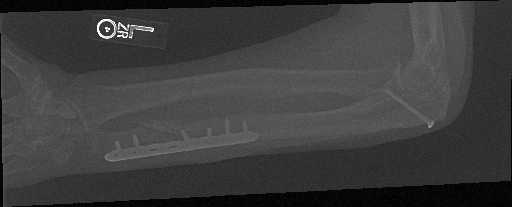

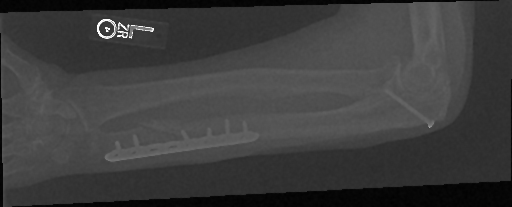

In [273]:
img = filtro_bilateralBW(noisy_img, 3, 1.5, 25)
img = np.clip(np.rint(img), 0, 255).astype(np.uint8)
cv2_imshow(noisy_img)
cv2_imshow(img)

### Aguçamento
Unsharp masking

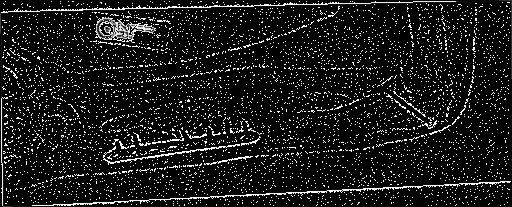

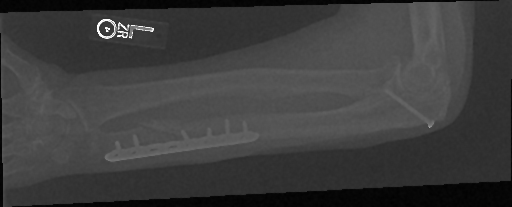

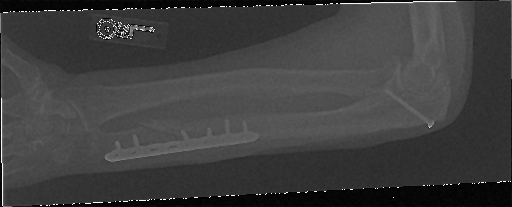

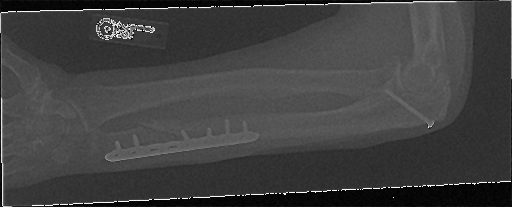

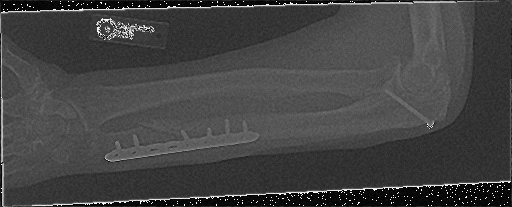

In [274]:
def obterLaplaciano(img):
  # Float permite fazer as somas sem overflow de uint8
  original = img.astype(np.float64)
  laplaciano = np.zeros(img.shape, np.uint8)

  # Nesta implementação, as bordas permanecem iguais às originais
  for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
      laplaciano[i, j] = (
        original[i - 1, j] +
        original[i + 1, j] +
        original[i, j - 1] +
        original[i, j + 1] +
        original[i, j]*-4
      )

  # for i in range(1, img.shape[0] - 1):
  #   for j in range(1, img.shape[1] - 1):
  #     laplaciano[i, j] = (
  #       original[i - 1, j - 1] +
  #       original[i - 1, j] +
  #       original[i - 1, j + 1] +
  #       original[i, j - 1] +
  #       original[i, j + 1] +
  #       original[i + 1, j - 1] +
  #       original[i + 1, j] +
  #       original[i + 1, j + 1] +
  #       original[i, j]*-8
  #     )

  return laplaciano

def obterLaplacianoBorrado(img):
  # Float permite fazer as somas sem overflow de uint8
  original = img.astype(np.float64)
  laplaciano = np.zeros(img.shape, np.uint8)

  # Nesta implementação, as bordas permanecem iguais às originais
  for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
      laplaciano[i, j] = (
        original[i - 1, j] +
        original[i + 1, j] +
        original[i, j - 1] +
        original[i, j + 1]
      )/4

  return laplaciano.astype(np.uint8)

# img = cv2.imread('image1.png',0)

img_laplaciano = obterLaplacianoBorrado(img)

mask = img - img_laplaciano

cv2_imshow(mask)

cv2_imshow(img)
cv2_imshow(img + mask*1)
cv2_imshow(img + mask*2)
cv2_imshow(img + mask*5)

img = img + mask*5

# print("------")

# img_laplaciano = obterLaplaciano(img)

# img_realcada = img - img_laplaciano*2

# cv2_imshow(img_realcada)